<a href="https://colab.research.google.com/github/oooinr4018-web/-1/blob/main/ESAA%EA%B3%BC%EC%A0%9C_0911%EC%9D%98_%EC%82%AC%EB%B3%B8%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 토픽 모델링 (Topic Modeling) - 뉴스그룹

토픽 모델링 (Topic Modeling): 문서 집합에 숨어 있는 주제 찾아내는 것

- 머신러닝 기반 토픽 모델링 적용

- 숨겨진 주제 표현 중심 단어 함축적 추줄

- 기법:  LSA(Latent Semantic nalysis), LDA(Latent Dirichlet Allocatin =/ Linear Discriminant Analysis)












# LDA

- LatentDirichletAllocation 클래스 제공

- Count 기반의 벡터화만 사용

(초기 버전 LDA의 토픽 모델링 제공 X -> gensim 패키지 등장과 함께 사이킷런의 LDA 제공)

- fetch_20newsgroups(): categories 파라미터로 필요한 주제 필터링 추출, Count 기반 벡터화 변환


토픽 모델링 예제) 20 뉴스그룹 데이터 세트

- 20가지 주제의 뉴스그룹 데이터

- 8개의 주제 추출 -> 텍스트에 LDA 기반 토픽 모델링 적용


In [22]:
# max_features=1000으로 word 피처의 개수 제한
# ngram_range=(1,2)로 설정

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# 모터사이클, 야구, 그래픽스, 윈도우즈, 중동, 기독교. 전자공학. 의학 8개 주제를 추출.
cats=['rec.motorcycles', 'rec.sport.baseball', 'comp.graphics', 'comp.windows.x',
      'talk.politics.mideast', 'soc.religion.christian', 'sci.electronics', 'sci.med']

# 위에서 cats 변수로 기재된 카테고리만 추출. fetch_20newsgroups()의 categories에 cats 입력
news_df=fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'),
                           categories=cats, random_state=0)
# LDA는 Count 기반의 벡터화만 적용합니다.
count_vect=CountVectorizer(max_df=0.95, max_features=1000, min_df=2, stop_words='english',
                           ngram_range=(1,2))
feat_vect=count_vect.fit_transform(news_df.data)
print('CountVectorizer Shape:', feat_vect.shape)

CountVectorizer Shape: (7862, 1000)


- CountVectorizer 객체 변수 feat_vct: 7862개의 문서, 1000개의 피처

In [23]:
# 토픽 개수 8개
#n_components 파라미터로 토픽 개수조정
# 예제 수행할 때마다 결과 같게 하기 위해 같은 random_state

lda=LatentDirichletAllocation(n_components=8, random_state=0)
lda.fit(feat_vect)

LatentDirichletAllocation(n_components=8, random_state=0)

- LatentDirichletAllocation.fit(데이터 세트) 수행 -> LatentDirichletAoolcation 객체 components_ 속성값 가짐.

*components_: 개별 토픽별로 각 word 피처가 그 토픽에 얼만큼 할당되었는지에 대한 수치





In [24]:
print(lda.components_.shape)
lda.components_

(8, 1000)


array([[2.69030238e+02, 1.87798026e+02, 7.09003824e+01, ...,
        1.22710343e+01, 1.06329639e+02, 7.25995512e+01],
       [1.25091799e-01, 2.46049106e+00, 1.25051902e-01, ...,
        2.80071176e+02, 1.25089783e-01, 5.05669662e+01],
       [1.33978420e+02, 1.25042012e-01, 9.98277256e+01, ...,
        1.25092219e-01, 3.31078261e+01, 1.25028398e-01],
       ...,
       [2.98813886e+01, 1.88071366e+01, 1.14748730e+01, ...,
        1.93022584e+01, 5.29368271e+00, 1.44478198e+01],
       [1.25074899e-01, 1.25105300e-01, 1.25004235e-01, ...,
        1.03576436e+02, 1.25100535e-01, 7.22276359e+01],
       [1.25172284e-01, 1.03967760e+00, 1.25221075e-01, ...,
        5.31740996e+01, 1.25025929e-01, 1.25062991e-01]])

- components_: array[8,1000]으로 구성

(8개의 토픽별로 1000개의 word 피처가 해당 토픽별로 연관도 값 가짐.)

- components_array_의 0번째 row, 10번째 col에 있는 값이, Topic #0에 대해 피처 벡터화된 행렬에서 10번째 칼럼에 해당하는 피처가 Topic#0에 연관되는 수치 값 가짐.

- lda_model.components_ 값만으로 각 토픽별 word 연관도 확인하기 어려움.

  



In [25]:
# display_topics() 함수 생성하여, 각 토픽별 연관도가 높은 순으로 Word 나열

def display_topics(model, feature_names, no_top_words):
  for topic_index, topic in enumerate(model.components_):
    print('Topic #', topic_index)

    # components_array에서 가장 값이 큰 순으로 정렬했을 때, 그 값의 array 인덱스를 반환.
    topic_word_indexes=topic.argsort()[::-1]
    top_indexes=topic_word_indexes[:no_top_words]

    # top_indexes 대상인 인덱스별로 feature_names에 해당하는 word feature 추출 후 join으로 concat
    feature_concat=' '.join([feature_names[i] for i in top_indexes])
    print(feature_concat)

# CountVectorizer 객체 내의 전체 word이 명칭을 get_features_names()를 통해 추출
feature_names=count_vect.get_feature_names_out()

# 토픽별 가장 연관도가 높은 word를 15개만 추출
display_topics(lda, feature_names, 15)

Topic # 0
10 year medical health 1993 20 12 disease cancer team patients research number new 11
Topic # 1
don just like know think good time ve does way really people want ll right
Topic # 2
image file jpeg output program gif images format files color entry use bit 03 02
Topic # 3
armenian armenians turkish people said turkey armenia government genocide turks muslim russian greek azerbaijan killed
Topic # 4
israel jews dos jewish israeli dos dos arab state people arabs palestinian adl ed anti peace
Topic # 5
edu com available graphics ftp window use mail data motif software version pub information server
Topic # 6
god people jesus church believe say christ does christian think christians did know bible man
Topic # 7
thanks use using does help like display need problem know server screen windows window program


- Topic #0: 일부 불분명한 주제어, 주로 의학 관련 주제어

- Topic#1: 명확하지 않은 일반적인 단어

- Topic#2: 컴퓨터 그래픽스 영역의 주제어

- Topic#3: 일반적인 단어

- Topic#4: 중동 영역의 주제어

- Topic#5: 일부 컴퓨터 그래픽스 영역의 주제어, 전반적인 컴퓨터 관련 용어

- Topic#6: 기독교 관련 주제어

- Topic#7: 윈도우 운영체제와 관련된 주제어

- 전체적인 관점: Topic #1,3,5 애매한 주제어, 야구 주제의 경우 명확한 주제어 X



# 문서 유사도 측정 방법 -코사인 유사도

코사인 유사도(Cosine Similarity)를 이용한 문서 간 유사도 비교

- 코사인 유사도

: 벡터와 벡터 간 유사도 비교 시, 벡터의 크기보다 벡터의 상호 방향성이 얼마나 유사한지에 기반

: 희소 행렬 기반 문사와 문서 간 크기 기반 유사도 지표(유클리드거리 기반 지표)는 정확도가 낮음.

:두 벡터 사잇각 (유사 정도 수치로 표시)

- similarity = cos(세타) = 두 벡터의 내적을 총 벡터 크기의 합으로 나눈 값

- 상호 관계: 유사, 관련 X, 반대 관계




In [26]:
# 서로 간의 문서 유사도를 코사인 유사도 기반으로 구해보기ㅣ

import numpy as np

def cos_similarity(v1, v2):
  dot_product=np.dot(v1,v2)
  l2_norm=(np.sqrt(sum(np.square(v1)))*np.sqrt(sum(np.square(v2))))
  similarity=dot_product/l2_norm

  return similarity
# doc_list로 정의된 3개의 간단한 문서의 유사도 비교
# 문서를 TF-IDF로 벡터화된 행렬로 변환

from sklearn.feature_extraction.text import TfidfVectorizer

doc_list=['if you take the blue pill, the story ends',
          'if you take the red pill, you stay in Wonderland',
          'if you take the red pill, I show you how deep the rabbit hole goes']

tfidf_vect_simple=TfidfVectorizer()
feature_vect_simple=tfidf_vect_simple.fit_transform(doc_list)
print(feature_vect_simple.shape)

(3, 18)


In [27]:
# 반환 행렬은 희소 행렬
# cos_similarity() 함수의 인자인 array로 만들기 위해, 밀집 행렬로 변환 후 다시 각각을 배열로 변환

# TfidfVectorizer로 transform)한 결과는 희소 행렬이므로 밀집 행렬로 변환.
feature_vect_dense=feature_vect_simple.todense()

# feature_vect_dense[0]은 doc_list 첫 번째 문서의 피처 벡터화
# feature_vect_dense[1]은 doc_list 두 번째 문서의 피처 벡터화
# 첫 번째 문장과 두 번째 문장의 피처 벡터 추출
vect1=np.array(feature_vect_dense[0]).reshape(-1, )
vect2=np.array(feature_vect_dense[1]).reshape(-1, )

# 첫 번째 문장과 두 번째 문장의 피처 벡터로 두 개 문장의 코사인 유사도 추출
similarity_simple=cos_similarity(vect1, vect2)
print('문장 1, 문장 2 cosine 유사도: {0:.3f}'.format(similarity_simple))


문장 1, 문장 2 cosine 유사도: 0.402


- 첫 번째 문장, 두 번째 문장의 코사인 유사도 = 0.402

In [28]:
vect1=np.array(feature_vect_dense[0]).reshape(-1, )
vect3=np.array(feature_vect_dense[2]).reshape(-1, )
similarity_simple=cos_similarity(vect1, vect3)
print('문장 1, 문장 3 cosine 유사도: {0:.3f}'.format(similarity_simple))

vect2=np.array(feature_vect_dense[1]).reshape(-1, )
vect3=np.array(feature_vect_dense[2]).reshape(-1, )
similarity_simple=cos_similarity(vect2, vect3)
print('문장 2, 문장 3 cosine 유사도: {0:.3f}'.format(similarity_simple))

문장 1, 문장 3 cosine 유사도: 0.404
문장 2, 문장 3 cosine 유사도: 0.456


- 사이킷런의 코사인 유사도 측정: sklearn.metrics.pairwise.cosine_similarity API

- cosine_similarity()

(1) 희소 행렬, 밀집 행렬 모두 가능 & 행렬, 배열 모두 가능 (별도의 변환 과정 X)

(2) 함수의 두 개의 입력 파라미터

첫 번째 파라미터: 비교 기준이 되는 문서의 피처 행렬,

두 번째 파라미터: 비교되는 문서의 피처 행렬

In [29]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_simple_pair=cosine_similarity(feature_vect_simple[0], feature_vect_simple)
print(similarity_simple_pair)


[[1.         0.40207758 0.40425045]]


- 첫 번째 유사도 값 1: 비교 기준인 첫 번째 문서 자신에 대한 유사도 측정

- 두 번째 유사도 값 0.40207758: 첫 번째, 두 번째 문서의 유사도

- 세 번째 유사도 값0.40425045: 첫 번째, 세 번째 문서의 유사도



In [30]:
# 유사도 측정 값 1을 제외

from sklearn.metrics.pairwise import cosine_similarity

similarity_simple_pair=cosine_similarity(feature_vect_simple[0], feature_vect_simple[1:])
print(similarity_simple_pair)

[[0.40207758 0.40425045]]


In [31]:
# cosine_similarity()를 쌍으로 코사인 유사도 값 제공
# 1번째 문서와 2,3번째 문서의 코사인 유사도
# 2번째 문서와 1,3번째 문서의 코사인 유사도
# 3번째 문서와 1,2번째 문서의 코사인 유사도

similarity_simple_pair=cosine_similarity(feature_vect_simple, feature_vect_simple)
print(similarity_simple_pair)
print('shape:', similarity_simple_pair.shape)


[[1.         0.40207758 0.40425045]
 [0.40207758 1.         0.45647296]
 [0.40425045 0.45647296 1.        ]]
shape: (3, 3)


- 반환 값 (3.3) 형태의 ndarray

- 첫 번째 row: 1번 문서와 2,3번째 문서의 코사인 유사도

- 두 번째 row: 2번 문서와 1,3번째 문서의 코사인 유사도

- 세 번째 row: 3번 문서와 1,2번째 문서의 코사인 유사도

# Opinion Review 데이터 세트를 이용한 문서 유사도 측정

Opinion Review 데이터 세트를 이용한 문서 간 유사도 측정

데이터 세트 -> DataFrame으로 로드 -> 문서 군집화 적용

In [39]:
# OpinosisDataset1.0/topics/*.data 파일 다운로드
!wget -O opinosis.zip "https://archive.ics.uci.edu/static/public/191/opinosis%2Bopinion%2Bfrasl%2Breview.zip"
!unzip -q opinosis.zip -d /content/opinosis

--2026-09-09 11:58:12--  https://archive.ics.uci.edu/static/public/191/opinosis%2Bopinion%2Bfrasl%2Breview.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘opinosis.zip’

opinosis.zip            [   <=>              ] 755.70K  1.14MB/s    in 0.6s    

2026-09-09 11:58:13 (1.14 MB/s) - ‘opinosis.zip’ saved [773840]

replace /content/opinosis/OpinosisDataset1.0/examples/prepare4rouge/input/summaries-base/accuracy_garmin_nuvi_255W_gps.baseline? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [40]:
# 실제 topics 위치 확인

import os

for root, dirs, files in os.walk('/content/opinosis'):
    if 'topics' in dirs:
        print(os.path.join(root, 'topics'))

/content/opinosis/OpinosisDataset1.0/topics


In [41]:
import pandas as pd
import glob, os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# 필수 NLTK 데이터 다운로드
nltk.download('punkt')
nltk.download('punkt_tab')

nltk.download('wordnet')

def LemNormalize(text):
  lemmatizer = WordNetLemmatizer()
  return [lemmatizer.lemmatize(token) for token in word_tokenize(text)]

path = '/content/opinosis/OpinosisDataset1.0/topics'
all_files=glob.glob(os.path.join(path, "*.data"))
filename_list=[]
opinion_text=[]

for file_ in all_files:
  df=pd.read_table(file_, index_col=None, header=0, encoding='latin1')
  filename_=file_.split('\\')[-1]
  filename=filename_.split(',')[0]
  filename_list.append(filename)
  opinion_text.append(df.to_string())

#
document_df = pd.DataFrame({
    'filename': ['doc1', 'doc2', 'doc3', 'doc4', 'doc5', 'doc6'],
    'opinion_text': [
        'The hotel room was clean and comfortable',
        'The hotel staff was friendly and helpful',
        'The phone battery life was very good',
        'The battery lasted all day',
        'The car was fast and easy to drive',
        'The vehicle had good handling and speed'
    ]
})

tfidf_vect=TfidfVectorizer(tokenizer=LemNormalize, stop_words='english',
                           ngram_range=(1,2), min_df=0.05, max_df=0.85 )
feature_vect=tfidf_vect.fit_transform(document_df['opinion_text'])

km_cluster=KMeans(n_clusters=3, max_iter=10000, random_state=0)
km_cluster.fit(feature_vect)
cluster_label=km_cluster.labels_
cluster_centers=km_cluster.cluster_centers_
document_df['cluster_label']=cluster_label

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
/usr/local/lib/python3.13/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ha', 'u', 'wa'] not in stop_words.
  warnings.warn(


# 결과

- 전자제품, 호텔, 자동차 주제로 군집화 진행




- 호텔을 주제로 군집화된 문서 이용

- 피처 벡터화된 데이터를 cosine_simularity()를 이용하여 유사도 확인

- 호텔을 주제로 한 군집화된 데이터 추출 -> TfidfVectorizer의 데이터 추출

(별도의 TF-IDF 벡터화 X)

- 과정

1. DataFrame 객체 변수 document_df에서 호텔로 군집화된 문서의 인덱스 추출

2. TfidfVectorizer 객체 변수 feature_vect에서 호텔로 피처화된 문서의 피처 벡터 추출

In [45]:
from sklearn.metrics.pairwise import cosine_similarity

# cluster_label=2인 데이터는 호텔로 군집화된 데이터임. DatFrame에서 해당 인덱스를 추출
hotel_indexes=document_df[document_df['cluster_label']==2].index
print('호텔로 클러스터링 된 문서들의 DataFrame Index:', hotel_indexes)

# 호텔로 군집화된 데이터 중 첫 번째 문서를 추출해 파일명 표시.
comparison_docname=document_df.iloc[hotel_indexes[0]]['filename']
print('##### 비교 기준 문서명', comparison_docname, ' 와 타 문서 유사도#####')

'''document_df에서 추출한 Index 객체를 feature_vect로 입력해 호텔 군집화된 feature_vect 추출
이를 이용해 호텔로 군집화된 문서 중 첫 번째 문서와 다른 문서 간의 코사인 유사도 측정.'''
similarity_pair=cosine_similarity(feature_vect[hotel_indexes[0]], feature_vect[hotel_indexes])
print(similarity_pair)

호텔로 클러스터링 된 문서들의 DataFrame Index: Index([0, 1], dtype='int64')
##### 비교 기준 문서명 doc1  와 타 문서 유사도#####
[[1.         0.12765845]]


- 첫 번째 문서와 다른 문서 간 유사도가 높은 순으로 정렬, 시각화

- osine_similarity(): 쌍 형태의 ndarray 반환

-> reshape(-1): 차원 변경 -> 판다스 인덱스로 이용

가장 유사도가 큰 파일명 및 유사도:
 filename          doc2
similarity    0.127658
Name: 1, dtype: object


Text(0.5, 1.0, 'doc1')

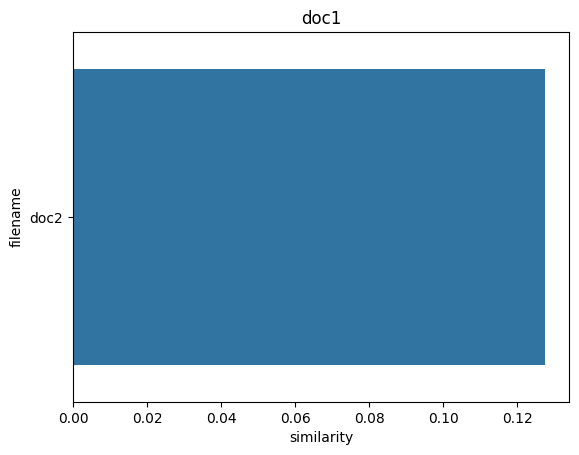

In [47]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# 첫번째 문서와 타 문서간 유사도가 큰 순으로 정렬한 인덱스 추출하되 자기 자신은 제외.
sorted_index=similarity_pair.argsort()[:,::-1]
sorted_index=sorted_index[:,1:]

# 유사도가 큰 순으로 hotel_indexes를 추출하여 재정렬.
hotel_sorted_indexes=hotel_indexes[sorted_index.reshape(-1)]

# 유사도가 큰 순으로 유사도 값을 재정렬하되 자기 자신은 제외
hotel_1_sim_value=np.sort(similarity_pair.reshape(-1))[::-1]
hotel_1_sim_value=hotel_1_sim_value[1:]

# 유사도가 큰 순으로 정렬된 인덱스와 유사도 값을 이용해 파일명과 유사도값을 막대 그래프로 시각화
hotel_1_sim_df=pd.DataFrame()
hotel_1_sim_df['filename']=document_df.iloc[hotel_sorted_indexes]['filename']
hotel_1_sim_df['similarity']=hotel_1_sim_value
print('가장 유사도가 큰 파일명 및 유사도:\n', hotel_1_sim_df.iloc[0,:])

sns.barplot(x='similarity', y='filename', data=hotel_1_sim_df)
plt.title(comparison_docname)

- 첫 번째 문서인 샌프란시스코의 베스트 웨스턴 호텔 화장실 리뷰(bathroom_bestwestern_hotel_sfo)와 가장 비슷한 문서 = room_holiday_inn_london

(코사인 유사도 값: 약 0.514)

# 한글 텍스트 처리 -네이버 영화 평점 감성 분석

네이버 영화 평점 데이터 기반 감성 분석

# 한글 NLP 처리의 어려움

- 띄어쓰기

- 다양한 조사


# KoNLPy 소개

KoNLPy

- 파이썬의 대표 한글 형태소 패키지

- 기존의 C/C++, Java로 만들어진 한글 형태소 엔진을 파이썬 래퍼(Wrapper) 기반으로 재작성한 패키지

- 파이썬 기반 인터페이스 제공 -> 검증된 패키지의 안정성 유지

- Mecab은 윈도우 환경에서 X

- 과정

1. OS 비트 수에 맞춘 파이썬 설치

2. 자바 설치 (1.7버전 이상, OS 비트수 일치)

3. JAVA_HOME 설정

4. 링크에서 OS 비트 수와 일치하는 JPype1 설치

(whi 파일로 설치하는 경우 pip로 업그레이드)

5. 명령프롬포트에서 KoNLPy 설치



In [76]:
!pip install --upgrade pip
!pip install JPype1

In [53]:
!pip install JPype1
!pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 44.8 MB/s  0:00:00


# 데이터 로딩

깃허브(github)에서 전체 데이터 세트 rating.txt, 학습 데이터 세트 ratings_train.txt, 테스트 데이터 세트 ratings_test.txt 내려받기

- 과정

1. 새로운 주피터 노트북 생성

2. 내려받은 파일 생성 주피터 노트북 디렉터리로 이동

In [77]:
# ratings_train.txt 파일 DataFrame으로 로딩
# Ratings_train.txt 파일은 탭(\n)으로 칼럼 분리되어있음. -> sep 파라미터 '\t'
# 한글 문서 DatFrame 로딩 시, 인코딩 이슈 발생 가능성 -> encoding cp949로 설정
import pandas as pd

train_df=pd.read_csv('ratings_train.txt', sep='\t', encoding='utf-8')
train_df.head(3)


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0


In [78]:
train_df['label'].value_counts()



,count
label,
0,75173
1,74827


결과

- 0,1의 균등한 분포



In [79]:
# - train_df의 리뷰 텍스트 'document' 칼럼에서 Null -> 공백 변환
# 문자가 아닌 숫자의 경우, 파이썬 정규 표현식 모듈 re -> 공백 변환

import re

train_df=train_df.fillna(' ')
# 정규 표현식을 이용해 숫자를 공백으로 변경 (정규 표현식으로 \d는 숫자를 의미함.)
train_df['document']=train_df['document'].apply(lambda x: re.sub(r"\d+", " ", x) )

# 테스트 데이터 세트를 로딩하고 동일하게 Null 및 숫자를 공백으로 변환
test_df=pd.read_csv('ratings_test.txt', sep='\t', encoding='utf-8')
test_df=test_df.fillna(' ')
test_df['document']=test_df['document'].apply(lambda x: re.sub(r"\d+", " ", x) )

# id 칼럼 삭제 수행
train_df.drop('id', axis=1, inplace=True)
test_df.drop('id', axis=1, inplace=True)

In [80]:
# 각 문장을 형태소 단어로 토큰화
# 형태소 엔진: Twitter 클래스 (SNS 분석에 적합)
# Twitter 객체의 morphs() 메서드: 입력 인자로 들어온 문장을 형태소 단어 형태로 토큰화해 list 객체로 반환
# tw_tokenizer(): 문장을 형태소 단어 형태로 반환하는 별도의 tokenizer 함수 (사이킷런의 TfidfVectorizer 클래스의 tokenizer)

from konlpy.tag import Twitter

twitter=Twitter()
def tw_tokenizer(text):
  # 입력 인자로 들어온 텍스트를 형태소 단어로 토큰화해 리스트 형태로 반환
  tokens_ko=twitter.morphs(text)
  return tokens_ko

/usr/local/lib/python3.13/dist-packages/konlpy/tag/_okt.py:17: UserWarning: "Twitter" has changed to "Okt" since KoNLPy v0.4.5.
  warn('"Twitter" has changed to "Okt" since KoNLPy v0.4.5.')


In [84]:
# 사이킷런의 TfidfVectorizer를 이용한 TF-IDF 피처 모델 생성
# tokenizer는 tw_tokenizer() 함수 이용
# ngram=(1,2), min_df=3, max_df=0.9로 제한

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Twitter 객체의 morphs() 객체를 이용한 tokenizer를 사용. ngram_range는 (1,2)
tfidf_vect=TfidfVectorizer(tokenizer=tw_tokenizer, ngram_range=(1,2), min_df=3, max_df=0.9)
tfidf_vect.fit(train_df['document'])
tfidf_matrix_train=tfidf_vect.transform(train_df['document'])

In [85]:
# 로지스틱 회귀를 이용해 감성 분석 분류 수행
lg_clf=LogisticRegression(random_state=0, solver='liblinear')

# 파라미터 C 최적화를 위해 GridSearchCV를 이용.
params={'C':[1, 3.5, 4.5, 5.5, 10] }
grid_cv=GridSearchCV(lg_clf, param_grid=params, cv=3, scoring='accuracy', verbose=1)
grid_cv.fit(tfidf_matrix_train, train_df['label'])
print(grid_cv.best_params_, round(grid_cv.best_score_, 4))

Fitting 3 folds for each of 5 candidates, totalling 15 fits
{'C': 3.5} 0.8593


# 결과
- C가 1일 때 최고 0.8593의 정확도

In [86]:
# 테스트 세트를 이용한 최종 감성 분석 예측
# 학습 시 적용한 TfidfVectorizer를 테스트 세트 예측 시 그대로 사용
# 학습 시 설정된 TfidfVectorizer 피처 개수와 테스트 데이터를 TfidfVectorizer로 변환할 피처 개수가 같아짐.
# TfidfVectorizer 객체 변수 tfidf_vect를 이용하여 transform()을 테스트 데이터의 document 칼럼에 수행

from sklearn.metrics import accuracy_score

# 학습 데이터를 적용한 TfidfVectorizer를 이용해 테스트 데이터를 TF-IDF 값으로 피처 변환함.
tfidf_matrix_test=tfidf_vect.transform(test_df['document'])

# classifier는 GridSearchCV에서 최적 파라미터로 학습된 classifier를 그대로 이용
best_estimator=grid_cv.best_estimator_
preds=best_estimator.predict(tfidf_matrix_test)

print('Logistic Regression 정확도: ', accuracy_score(test_df['label'], preds))

Logistic Regression 정확도:  0.86172
